In [9]:
!pip install pandas matplotlib numpy

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
%matplotlib inline

In [11]:
df_index = pd.read_csv("economic_index (1).csv")

In [12]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [15]:
## drop unneccessary columns
df_index.drop(columns=["Unnamed: 0", "year", "month"], inplace=True)

In [16]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [ ]:
## to check null value
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

In [18]:
## visualization
import seaborn as sns

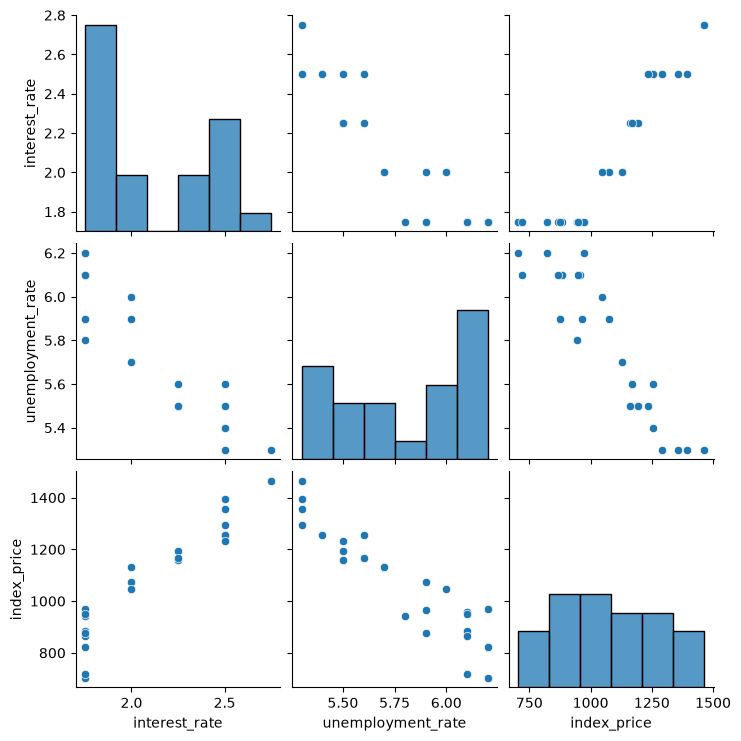

In [19]:
sns.pairplot(df_index)

In [20]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment rate')

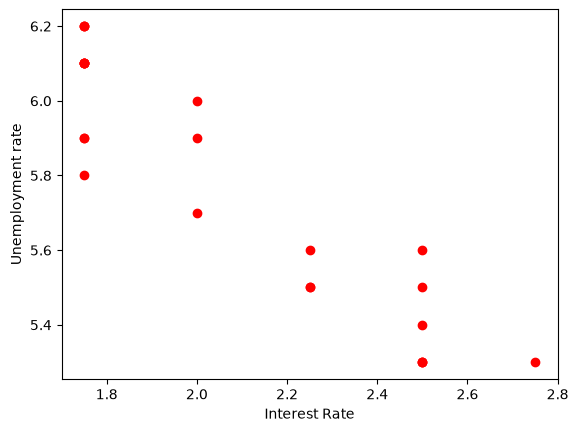

In [25]:
##visualize data points more clearly
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest Rate")
plt.ylabel("Unemployment rate")

In [28]:
## independent and dependent feature
X = df_index[['interest_rate', 'unemployment_rate']]
## X = df_index.iloc[:,:-1]

y = df_index.iloc[:,-1]

In [29]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [30]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [31]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.25, random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

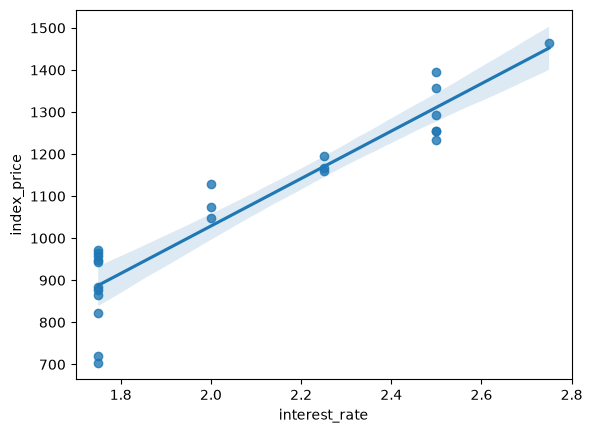

In [ ]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['index_price']
)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

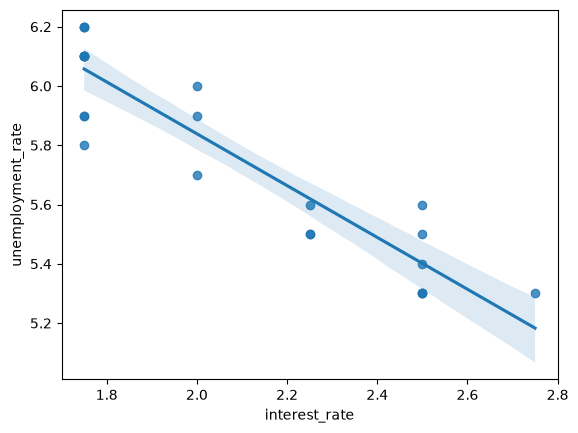

In [34]:
sns.regplot(
    x=df_index['interest_rate'],
    y=df_index['unemployment_rate']
)

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

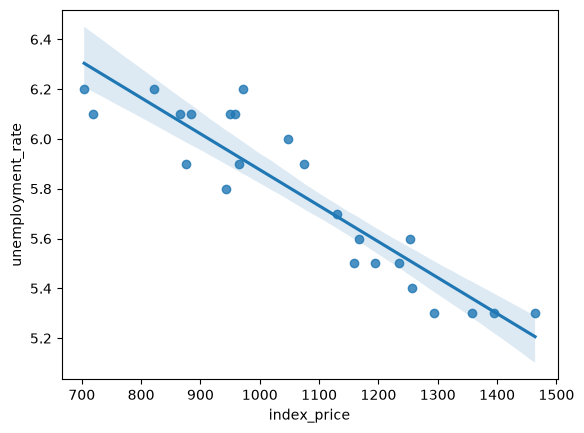

In [35]:
sns.regplot(
    x=df_index['index_price'],
    y=df_index['unemployment_rate']
)

In [36]:
from sklearn.preprocessing import StandardScaler


In [38]:
scaler = StandardScaler()
X_train=  scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [39]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [40]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()


In [41]:
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 88.27,-116.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


In [ ]:
## cross validation
from sklearn.model_selection import cross_val_score
validationscore = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3 )

In [47]:
np.mean(validationscore)

np.float64(-5914.828180162386)

In [48]:
## prediction
y_predict = regression.predict(X_test)

In [49]:
y_predict

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [50]:
## performance metrics
##performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [51]:
mse = mean_squared_error(y_test, y_predict)
mae = mean_absolute_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [52]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_predict)
print(score)

0.7591371539010257


In [53]:
1 - (1-score)*(len(y_test-1)-1)/(len(y_test) - X_test.shape[1]-1)

0.5985619231683761

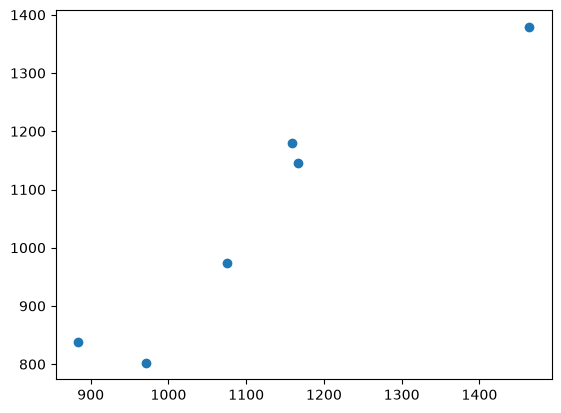

In [55]:
## assumptions
plt.scatter(y_test, y_predict)

In [58]:
residuals = y_test-y_predict
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


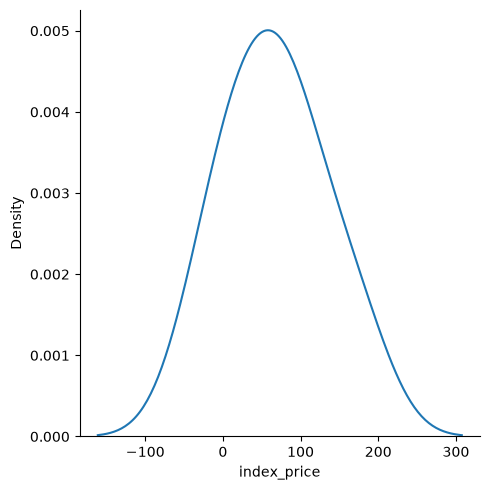

In [60]:
## plot the residuals
sns.displot(residuals, kind=  'kde')

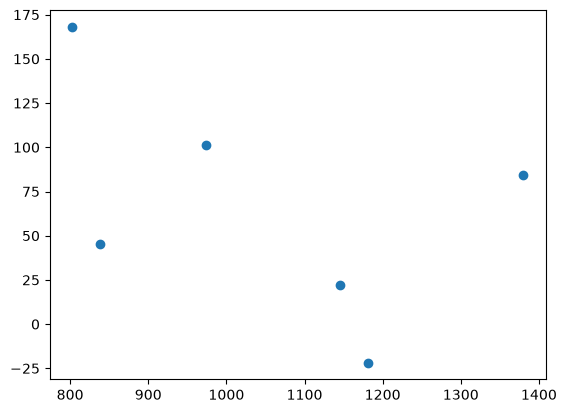

In [62]:
## scatter plot wrtn prediction and residuals
plt.scatter(y_predict, residuals)
